In [ ]:
from pathlib import Path
import sys
import numpy as np

# Make cross-subject package importable when running from notebooks/.
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from destine_dataset import (
    DEFAULT_CHANNEL_NAMES,
    discover_recordings,
    load_freq_phase,
    load_data_from_users,
    build_tensors_no_cca,
    build_tensors_with_cca,
    )

print(f"Project root: {ROOT}")

Project root: /home/mateuschinelatto/Experiments/ssvep-bci-nn/cross-subject


In [2]:
# Full DESTINE dataset path
DATASET_PATH = Path("/home/mateuschinelatto/Experiments/data/DESTINE")
assert DATASET_PATH.exists(), f"Dataset path not found: {DATASET_PATH}"
print("Dataset path:", DATASET_PATH)

subjects_on_disk = sorted([p.name.lower() for p in DATASET_PATH.iterdir() if p.is_dir()])
print("Subjects on disk:", subjects_on_disk)

Dataset path: /home/mateuschinelatto/Experiments/data/DESTINE
Subjects on disk: ['carlos', 'george', 'guilherme', 'harlei', 'heiko', 'joao', 'luis', 'luisa', 'sarah', 'thiago']


In [3]:
# Discover files in DESTINE and summarize frequencies/sessions per subject
recordings = discover_recordings(DATASET_PATH)
subjects = sorted(recordings.keys())
print(f"Discovered {len(subjects)} subjects")

for subject in subjects:
    freqs = sorted(recordings[subject].keys())
    session_counts = {f: len(recordings[subject][f]) for f in freqs}
    print(f"- {subject}: freqs={freqs}, sessions_per_freq={session_counts}")

Discovered 11 subjects
- carlos: freqs=[0.0, 6.0, 7.5, 12.0, 15.0, 20.0, 30.0], sessions_per_freq={0.0: 8, 6.0: 8, 7.5: 8, 12.0: 8, 15.0: 8, 20.0: 8, 30.0: 8}
- george: freqs=[0.0, 6.0, 7.5, 12.0, 15.0, 20.0, 30.0], sessions_per_freq={0.0: 8, 6.0: 8, 7.5: 8, 12.0: 8, 15.0: 8, 20.0: 8, 30.0: 8}
- guilherme: freqs=[0.0, 6.0, 7.5, 12.0, 15.0, 20.0, 30.0], sessions_per_freq={0.0: 8, 6.0: 8, 7.5: 8, 12.0: 8, 15.0: 8, 20.0: 8, 30.0: 8}
- harlei: freqs=[0.0, 6.0, 7.5, 12.0, 15.0, 20.0, 30.0], sessions_per_freq={0.0: 8, 6.0: 8, 7.5: 8, 12.0: 8, 15.0: 8, 20.0: 8, 30.0: 8}
- heiko: freqs=[0.0, 6.0, 7.5, 12.0, 15.0, 20.0, 30.0], sessions_per_freq={0.0: 8, 6.0: 8, 7.5: 8, 12.0: 8, 15.0: 8, 20.0: 8, 30.0: 8}
- joao: freqs=[0.0, 6.0, 7.5, 12.0, 15.0, 20.0, 30.0], sessions_per_freq={0.0: 8, 6.0: 8, 7.5: 8, 12.0: 8, 15.0: 8, 20.0: 8, 30.0: 8}
- luis: freqs=[0.0, 6.0, 7.5, 12.0, 15.0, 20.0, 30.0], sessions_per_freq={0.0: 8, 6.0: 8, 7.5: 8, 12.0: 8, 15.0: 8, 20.0: 8, 30.0: 8}
- luisa: freqs=[0.0, 6.0, 7

In [4]:
# Infer frequencies/phases in benchmark-compatible format
frequencias_all, fases_all = load_freq_phase(DATASET_PATH)
print("All discovered frequencies:", frequencias_all.tolist())
print("Phases placeholder:", fases_all.tolist())

All discovered frequencies: [0.0, 6.0, 7.5, 10.0, 12.0, 15.0, 20.0, 30.0]
Phases placeholder: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [5]:
# Load a subset of users with preprocessing (bandpass + local CAR)
users = ["sarah", "joao", "luisa"]
target_freqs = [6.0, 7.5, 12.0, 15.0, 20.0, 30.0]
target_sessions = list(range(1, 9))

all_data = load_data_from_users(
    users=users,
    dataset_path=DATASET_PATH,
    frequencies=target_freqs,
    sessions=target_sessions,
    filter_bandpass=True,
    sample_rate=256,
    freq_cut_low=5,
    freq_cut_high=100,
    filter_order=4,
    apply_car=True,
    car_mode="local",
)

print("Loaded users:", len(all_data))
for user, data in zip(users, all_data):
    print(f"{user}: shape={data.shape}  -> (channels, time, freqs, trials)")

Loading DESTINE users:   0%|          | 0/3 [00:00<?, ?it/s]

Loading DESTINE users: 100%|██████████| 3/3 [00:02<00:00,  1.04it/s]

Loaded users: 3
sarah: shape=(16, 3072, 6, 8)  -> (channels, time, freqs, trials)
joao: shape=(16, 3072, 6, 8)  -> (channels, time, freqs, trials)
luisa: shape=(16, 3072, 6, 8)  -> (channels, time, freqs, trials)


In [6]:
# Build non-CCA tensors (directly plug into DNN/EEGNet experiments)
frequencias = np.array(target_freqs, dtype=np.float32)
indices = list(range(len(frequencias)))
occipital_electrodes = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8])  # O1..PO8
tamanho_da_janela = 512  # 2s at 256 Hz

test_user_idx = 0
test_data = all_data[test_user_idx]
train_data = np.concatenate([all_data[i] for i in range(len(all_data)) if i != test_user_idx], axis=3)

x_train, x_test, y_train, y_test, channels_for_model = build_tensors_no_cca(
    train_data=train_data,
    test_data=test_data,
    occipital_electrodes=occipital_electrodes,
    frequencias=frequencias,
    indices=indices,
    tamanho_da_janela=tamanho_da_janela,
    apply_subband_filter=False,
    sampling_rate=256,
)

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("len(y_train):", len(y_train), "len(y_test):", len(y_test))
print("channels_for_model:", channels_for_model)

[DESTINE] build_tensors_no_cca -> x_train=(96, 9, 512), x_test=(48, 9, 512), labels_train=96, labels_test=48, channels=9
x_train: (96, 9, 512)
x_test: (48, 9, 512)
len(y_train): 96 len(y_test): 48
channels_for_model: 9


In [7]:
# Validate build_tensors_no_cca outputs: shape, labels, and signal sanity
num_freqs = len(frequencias)
num_trials_train = train_data.shape[-1]
num_trials_test = test_data.shape[-1]

expected_train_samples = num_freqs * num_trials_train
expected_test_samples = num_freqs * num_trials_test

print("=== Shape checks ===")
print("x_train shape:", x_train.shape, "expected samples:", expected_train_samples)
print("x_test shape:", x_test.shape, "expected samples:", expected_test_samples)
print("channels_for_model:", channels_for_model, "expected channels:", len(occipital_electrodes))

assert x_train.shape[0] == len(y_train), "Mismatch: x_train samples vs y_train length"
assert x_test.shape[0] == len(y_test), "Mismatch: x_test samples vs y_test length"
assert x_train.shape[0] == expected_train_samples, "Unexpected train sample count"
assert x_test.shape[0] == expected_test_samples, "Unexpected test sample count"
assert channels_for_model == len(occipital_electrodes), "Unexpected channel count"

print("\n=== Label checks ===")
train_labels, train_counts = np.unique(np.array(y_train, dtype=np.float32), return_counts=True)
test_labels, test_counts = np.unique(np.array(y_test, dtype=np.float32), return_counts=True)
print("train label distribution:", dict(zip(train_labels.tolist(), train_counts.tolist())))
print("test label distribution:", dict(zip(test_labels.tolist(), test_counts.tolist())))
print("expected labels:", frequencias.tolist())

assert np.array_equal(np.sort(train_labels), np.sort(frequencias)), "Train labels do not match expected frequencies"
assert np.array_equal(np.sort(test_labels), np.sort(frequencias)), "Test labels do not match expected frequencies"
assert np.all(train_counts == num_trials_train), "Train label counts are not balanced as expected"
assert np.all(test_counts == num_trials_test), "Test label counts are not balanced as expected"

print("\n=== Signal checks ===")
assert np.isfinite(x_train).all(), "x_train contains NaN or inf"
assert np.isfinite(x_test).all(), "x_test contains NaN or inf"

# Per-sample variance across channel/time should be > 0 for real EEG segments.
train_var = np.var(x_train, axis=(1, 2))
test_var = np.var(x_test, axis=(1, 2))
print("train variance min/max:", float(train_var.min()), float(train_var.max()))
print("test variance min/max:", float(test_var.min()), float(test_var.max()))

assert np.all(train_var > 0), "Some train samples are constant (zero variance)"
assert np.all(test_var > 0), "Some test samples are constant (zero variance)"

print("\nAll build_tensors_no_cca validation checks passed.")

=== Shape checks ===
x_train shape: (96, 9, 512) expected samples: 96
x_test shape: (48, 9, 512) expected samples: 48
channels_for_model: 9 expected channels: 9

=== Label checks ===
train label distribution: {6.0: 16, 7.5: 16, 12.0: 16, 15.0: 16, 20.0: 16, 30.0: 16}
test label distribution: {6.0: 8, 7.5: 8, 12.0: 8, 15.0: 8, 20.0: 8, 30.0: 8}
expected labels: [6.0, 7.5, 12.0, 15.0, 20.0, 30.0]

=== Signal checks ===
train variance min/max: 0.6967282891273499 1.521212100982666
test variance min/max: 0.8028169870376587 1.3254743814468384

All build_tensors_no_cca validation checks passed.


In [8]:
# Learning sanity check: can EEGNet overfit a tiny subset?
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from braindecode.models import EEGNet

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

# Label mapping exactly like training scripts
mapping = {label: i for i, label in enumerate(sorted(frequencias))}
y_train_idx = np.array([mapping[float(v)] for v in y_train], dtype=np.int64)

# Tiny balanced subset: first 8 samples per class
subset_idx = []
for cls in sorted(np.unique(y_train_idx)):
    cls_idx = np.where(y_train_idx == cls)[0][:8]
    subset_idx.extend(cls_idx.tolist())
subset_idx = np.array(subset_idx, dtype=np.int64)

x_small = torch.tensor(x_train[subset_idx], dtype=torch.float32)
y_small = torch.tensor(y_train_idx[subset_idx], dtype=torch.long)

print("x_small:", tuple(x_small.shape), "y_small:", tuple(y_small.shape))
print("class counts:", np.bincount(y_small.numpy()))

small_loader = DataLoader(TensorDataset(x_small, y_small), batch_size=16, shuffle=True)

model = EEGNet(
    n_chans=x_small.shape[1],
    n_outputs=len(np.unique(y_train_idx)),
    n_times=x_small.shape[2],
    kernel_length=128,
    F1=8,
    D=2,
    drop_prob=0.25,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)

for epoch in range(1, 61):
    model.train()
    total_loss = 0.0
    total = 0
    correct = 0
    for xb, yb in small_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * yb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch={epoch:02d} loss={total_loss/total:.4f} acc={correct/total:.4f}")

print("Done. If acc stays near chance (~1/num_classes), model/pipeline likely has an issue.")

device: cuda:0
x_small: (48, 9, 512) y_small: (48,)
class counts: [8 8 8 8 8 8]
epoch=01 loss=1.8185 acc=0.1042
epoch=10 loss=1.5869 acc=0.6458
epoch=20 loss=1.3928 acc=0.6875
epoch=30 loss=1.1160 acc=0.8125
epoch=40 loss=0.7689 acc=0.9167
epoch=50 loss=0.5181 acc=0.9792
epoch=60 loss=0.2869 acc=0.9792
Done. If acc stays near chance (~1/num_classes), model/pipeline likely has an issue.


In [21]:
# Full-config reproduction (similar to run_destine_eegnet_experiments.py) on one held-out subject
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from braindecode.models import EEGNet

users_10 = ["carlos", "george", "guilherme", "harlei", "heiko", "joao", "luis", "luisa", "sarah", "thiago"]
freqs_6 = [6.0, 7.5, 12.0, 15.0, 20.0, 30.0]
sessions_8 = list(range(1, 9))
test_user = "sarah"

all_data_10 = load_data_from_users(
    users=users_10,
    dataset_path=DATASET_PATH,
    frequencies=freqs_6,
    sessions=sessions_8,
    filter_bandpass=True,
    sample_rate=256,
    freq_cut_low=6.0,
    freq_cut_high=50.0,
    filter_order=10,
    apply_car=True,
    car_mode="global",
    window_size=256,
    window_mode="single",
    window_overlap=None,
    strict=True,
 )

train_users = [u for u in users_10 if u != test_user]
train_data_10 = np.concatenate([all_data_10[users_10.index(u)] for u in train_users], axis=-1)
test_data_10 = all_data_10[users_10.index(test_user)]

# Use all available channels from the loaded dataset to avoid index mismatch across subjects.
occipital_n = np.arange(train_data_10.shape[0], dtype=int)
freq_arr_6 = np.array(freqs_6, dtype=np.float32)
indices_6 = list(range(len(freq_arr_6)))

x_train_10, x_test_10, labels_train_10, labels_test_10, channels_10 = build_tensors_no_cca(
    train_data=train_data_10,
    test_data=test_data_10,
    occipital_electrodes=occipital_n,
    frequencias=freq_arr_6,
    indices=indices_6,
    tamanho_da_janela=256,
    apply_subband_filter=False,
    sampling_rate=256,
 )

mapping_10 = {label: i for i, label in enumerate(sorted(freq_arr_6))}
y_train_10 = torch.tensor([mapping_10[float(v)] for v in labels_train_10], dtype=torch.long)
y_test_10 = torch.tensor([mapping_10[float(v)] for v in labels_test_10], dtype=torch.long)

print("x_train_10:", x_train_10.shape, "x_test_10:", x_test_10.shape)
print("train class counts:", np.bincount(y_train_10.numpy()))
print("test class counts:", np.bincount(y_test_10.numpy()))

x_train_10_t = torch.tensor(x_train_10, dtype=torch.float32)
dataset_10 = TensorDataset(x_train_10_t, y_train_10)
train_size_10 = int(0.85 * len(dataset_10))
val_size_10 = len(dataset_10) - train_size_10
train_ds_10, val_ds_10 = random_split(
    dataset_10,
    [train_size_10, val_size_10],
    generator=torch.Generator().manual_seed(42),
)

train_loader_10 = DataLoader(train_ds_10, batch_size=64, shuffle=True)
val_loader_10 = DataLoader(val_ds_10, batch_size=32, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_10 = EEGNet(
    n_chans=channels_10,
    n_outputs=len(freqs_6),
    n_times=256,
    kernel_length=128,
    F1=8,
    D=2,
    drop_prob=0.25,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_10.parameters(), lr=9e-4, weight_decay=6.8e-4)

for epoch in range(1, 31):
    model_10.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0
    for xb, yb in train_loader_10:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_10(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * yb.size(0)
        train_correct += (logits.argmax(dim=1) == yb).sum().item()
        train_total += yb.size(0)

    if epoch % 5 == 0 or epoch == 1:
        model_10.eval()
        val_correct = 0
        val_total = 0
        with torch.inference_mode():
            for xb, yb in val_loader_10:
                xb, yb = xb.to(device), yb.to(device)
                logits = model_10(xb)
                val_correct += (logits.argmax(dim=1) == yb).sum().item()
                val_total += yb.size(0)
        print(
            f"epoch={epoch:02d} train_loss={running_loss/max(1, train_total):.4f} "
            f"train_acc={train_correct/max(1, train_total):.4f} "
            f"val_acc={val_correct/max(1, val_total):.4f}"
        )

Loading DESTINE users:   0%|          | 0/10 [00:00<?, ?it/s]

Loading DESTINE users: 100%|██████████| 10/10 [00:02<00:00,  4.12it/s]


[DESTINE] build_tensors_no_cca -> x_train=(432, 16, 256), x_test=(48, 16, 256), labels_train=432, labels_test=48, channels=16
x_train_10: (432, 16, 256) x_test_10: (48, 16, 256)
train class counts: [72 72 72 72 72 72]
test class counts: [8 8 8 8 8 8]
epoch=01 train_loss=1.7922 train_acc=0.1553 val_acc=0.1538
epoch=05 train_loss=1.7914 train_acc=0.1553 val_acc=0.1077
epoch=10 train_loss=1.7910 train_acc=0.1689 val_acc=0.1231
epoch=15 train_loss=1.7909 train_acc=0.1826 val_acc=0.1077
epoch=20 train_loss=1.7907 train_acc=0.1662 val_acc=0.1231
epoch=25 train_loss=1.7904 train_acc=0.1907 val_acc=0.1231
epoch=30 train_loss=1.7894 train_acc=0.1853 val_acc=0.1077


In [22]:
# Intervention test: channel-wise z-score per sample
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from braindecode.models import EEGNet

x_norm = x_train_10.copy()
mean = x_norm.mean(axis=2, keepdims=True)
std = x_norm.std(axis=2, keepdims=True) + 1e-6
x_norm = (x_norm - mean) / std

x_norm_t = torch.tensor(x_norm, dtype=torch.float32)
dataset_norm = TensorDataset(x_norm_t, y_train_10)
train_norm, val_norm = random_split(
    dataset_norm,
    [int(0.85 * len(dataset_norm)), len(dataset_norm) - int(0.85 * len(dataset_norm))],
    generator=torch.Generator().manual_seed(42),
)
train_loader_norm = DataLoader(train_norm, batch_size=64, shuffle=True)
val_loader_norm = DataLoader(val_norm, batch_size=32, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model_norm = EEGNet(
    n_chans=channels_10,
    n_outputs=6,
    n_times=256,
    kernel_length=128,
    F1=8,
    D=2,
    drop_prob=0.25,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_norm.parameters(), lr=9e-4, weight_decay=6.8e-4)

for epoch in range(1, 31):
    model_norm.train()
    tr_loss = 0.0
    tr_corr = 0
    tr_tot = 0
    for xb, yb in train_loader_norm:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model_norm(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * yb.size(0)
        tr_corr += (out.argmax(1) == yb).sum().item()
        tr_tot += yb.size(0)

    if epoch % 5 == 0 or epoch == 1:
        model_norm.eval()
        va_corr = 0
        va_tot = 0
        with torch.inference_mode():
            for xb, yb in val_loader_norm:
                xb, yb = xb.to(device), yb.to(device)
                out = model_norm(xb)
                va_corr += (out.argmax(1) == yb).sum().item()
                va_tot += yb.size(0)
        print(
            f"[zscore] epoch={epoch:02d} train_loss={tr_loss/max(1, tr_tot):.4f} "
            f"train_acc={tr_corr/max(1, tr_tot):.4f} val_acc={va_corr/max(1, va_tot):.4f}"
        )

[zscore] epoch=01 train_loss=1.8024 train_acc=0.1417 val_acc=0.1077
[zscore] epoch=05 train_loss=1.7715 train_acc=0.2343 val_acc=0.2000
[zscore] epoch=10 train_loss=1.7346 train_acc=0.3079 val_acc=0.1692
[zscore] epoch=15 train_loss=1.6980 train_acc=0.3161 val_acc=0.0923
[zscore] epoch=20 train_loss=1.6462 train_acc=0.3624 val_acc=0.0923
[zscore] epoch=25 train_loss=1.6002 train_acc=0.3706 val_acc=0.1077
[zscore] epoch=30 train_loss=1.5656 train_acc=0.4114 val_acc=0.1231


In [9]:
# Build CCA tensors (plug into DNN+CCA / EEGNet+CCA experiments)
fases = np.zeros_like(frequencias, dtype=np.float32)
num_harmonica = 3
inform_fase = 0

tensor_train, tensor_test, labels_train, labels_test, channels_for_model = build_tensors_with_cca(
    train_data=train_data,
    test_data=test_data,
    occipital_electrodes=occipital_electrodes,
    frequencias=frequencias,
    fases=fases,
    indices=indices,
    num_harmonica=num_harmonica,
    inform_fase=inform_fase,
    tamanho_da_janela=tamanho_da_janela,
    mean_center=True,
    apply_subband_filter=False,
    subban_no=3,
    sampling_rate=256,
)

print("tensor_train:", tensor_train.shape)
print("tensor_test:", tensor_test.shape)
print("len(labels_train):", len(labels_train), "len(labels_test):", len(labels_test))

[DESTINE] build_tensors_with_cca -> x_train=(96, 6, 512), x_test=(48, 6, 512), labels_train=96, labels_test=48, channels=6
tensor_train: (96, 6, 512)
tensor_test: (48, 6, 512)
len(labels_train): 96 len(labels_test): 48


Sarah's data shape: (16, 3072, 6, 8)
Frequencies: [6.0, 7.5, 12.0, 15.0, 20.0, 30.0]
Number of channels: 16
Channel names: ['O1', 'O2', 'Oz', 'POz', 'Pz', 'PO3', 'PO4', 'PO7', 'PO8', 'P1', 'P2', 'Cz', 'C1', 'C2', 'CPz', 'FCz']
Oz is at channel index: 2


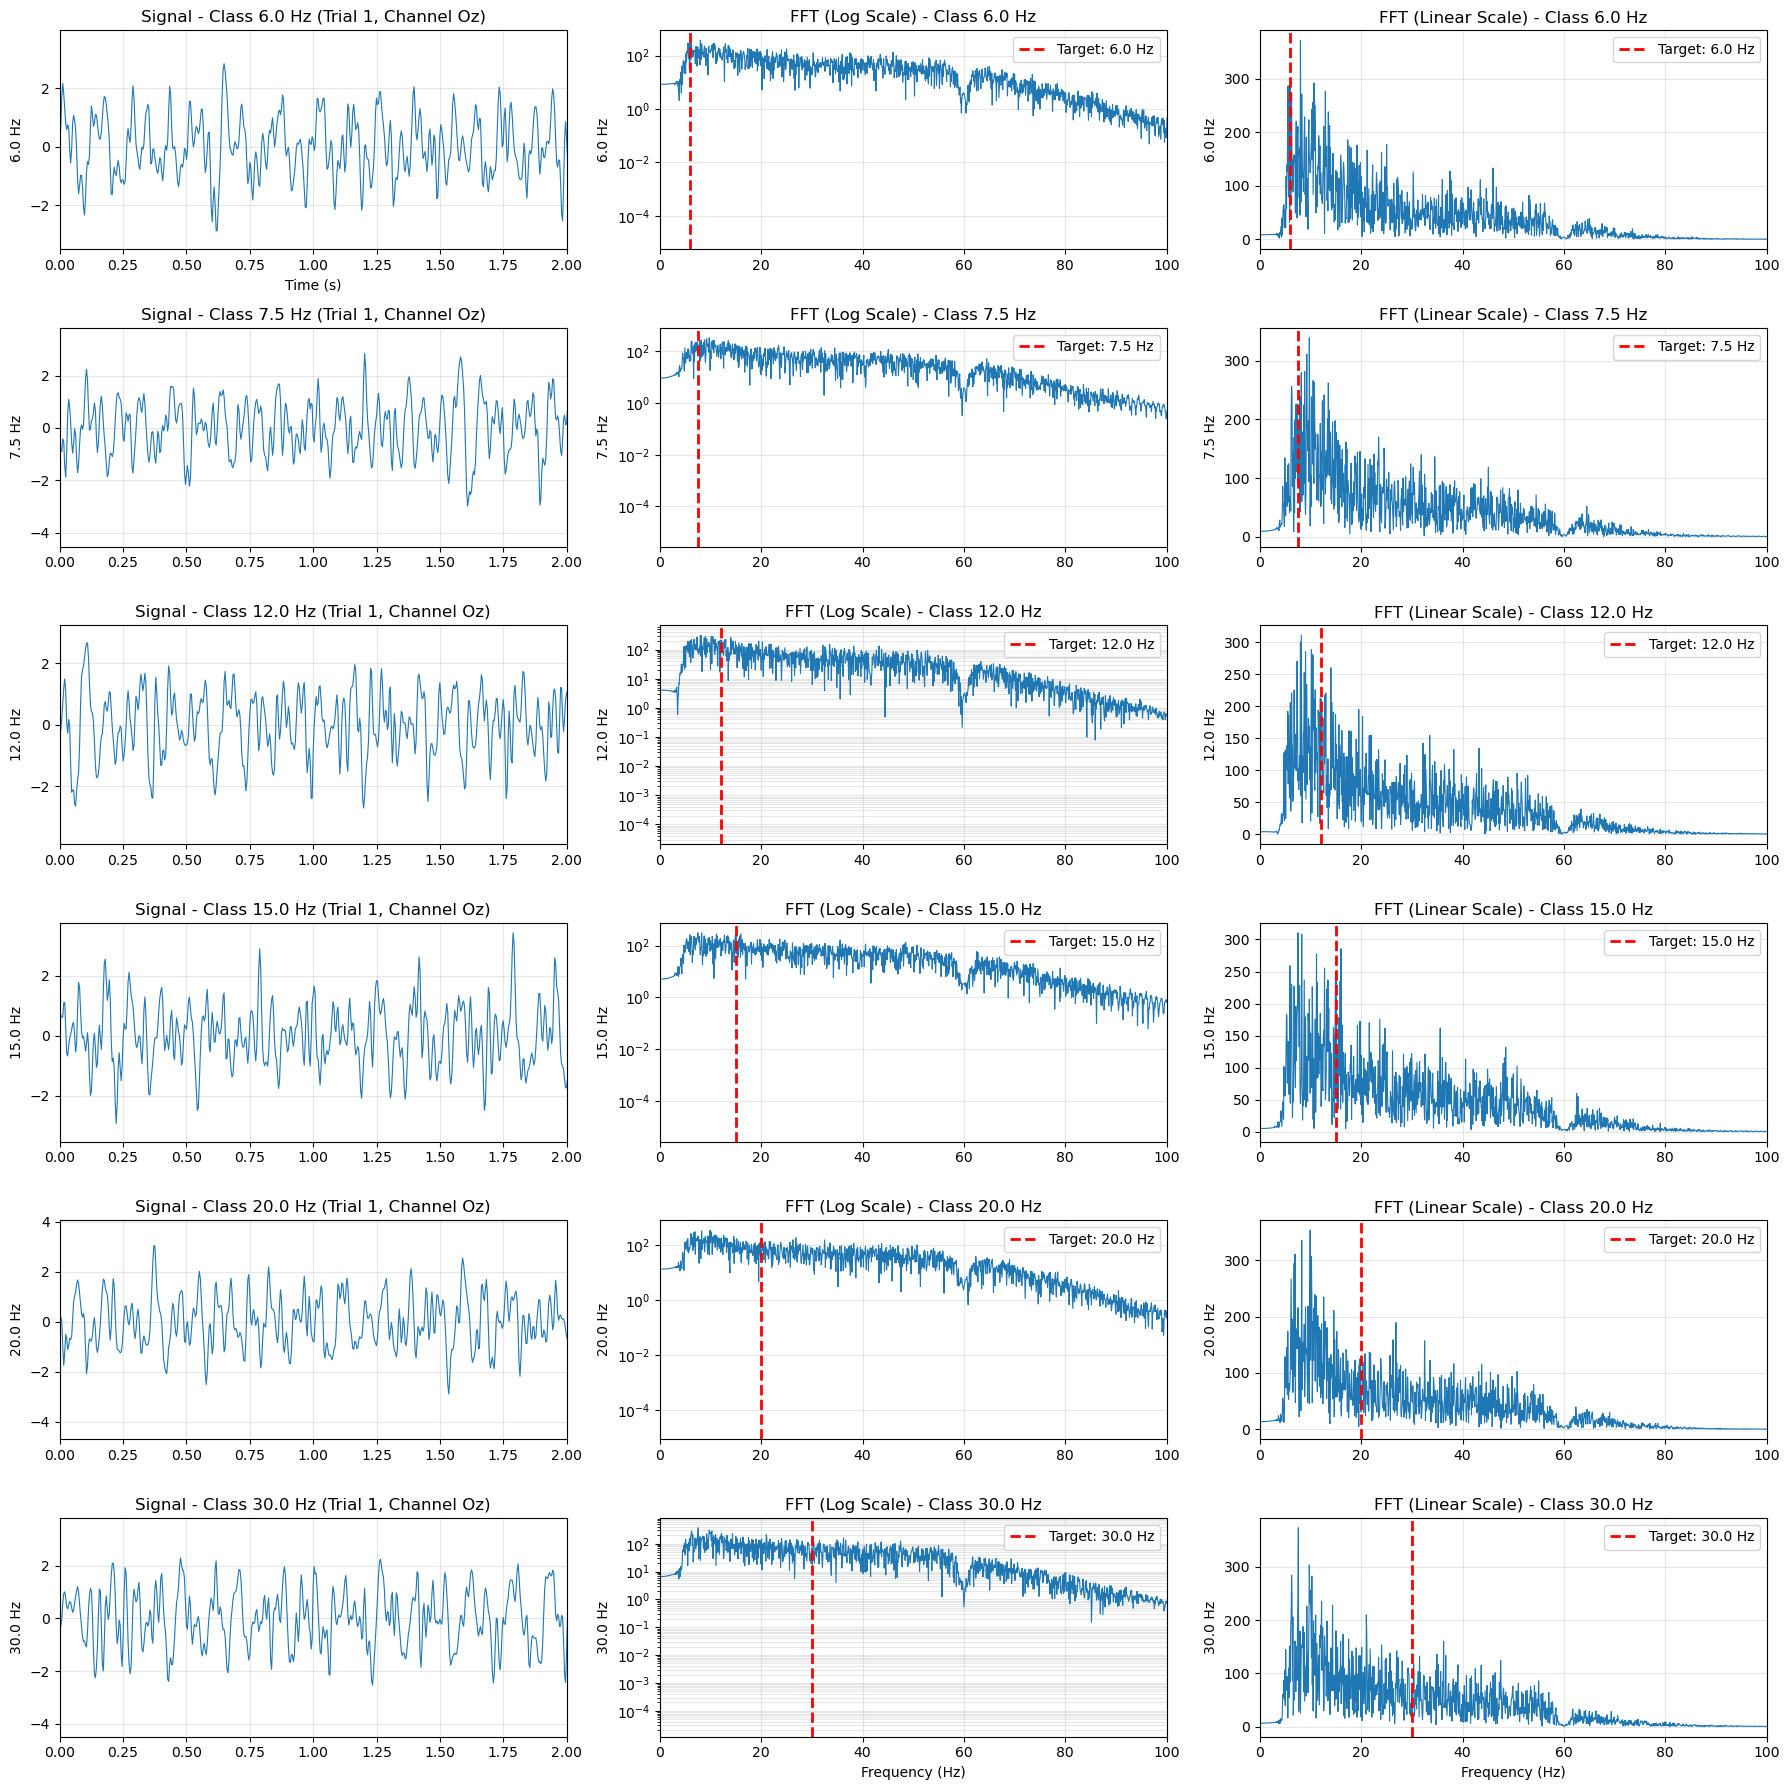


Plot saved to /tmp/sarah_signals_fft_oz.png

--- Class Distribution for Sarah ---
Frequency 6.0 Hz: 8 trials
Frequency 7.5 Hz: 8 trials
Frequency 12.0 Hz: 8 trials
Frequency 15.0 Hz: 8 trials
Frequency 20.0 Hz: 8 trials
Frequency 30.0 Hz: 8 trials


In [11]:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Extract Sarah's data (first in the list)
sarah_data = all_data[0]  # shape: (channels, time, freqs, trials)
print(f"Sarah's data shape: {sarah_data.shape}")
print(f"Frequencies: {target_freqs}")
print(f"Number of channels: {sarah_data.shape[0]}")
print(f"Channel names: {DEFAULT_CHANNEL_NAMES}")

# Find Oz channel index
oz_idx = DEFAULT_CHANNEL_NAMES.index('Oz')
print(f"Oz is at channel index: {oz_idx}")

# Visualize signals and FFT for each frequency class
num_freqs = len(target_freqs)
fig, axes = plt.subplots(num_freqs, 3, figsize=(18, 3*num_freqs))

for freq_idx, freq in enumerate(target_freqs):
    # Get first trial of this frequency class, Oz channel
    signal = sarah_data[oz_idx, :, freq_idx, 1]  # (time_samples,)
    
    # Time axis
    time = np.arange(len(signal)) / 256  # 256 Hz sampling rate
    
    # Plot time-domain signal
    axes[freq_idx, 0].plot(time, signal, linewidth=0.8)
    axes[freq_idx, 0].set_ylabel(f'{freq} Hz')
    axes[freq_idx, 0].set_title(f'Signal - Class {freq} Hz (Trial 1, Channel Oz)')
    axes[freq_idx, 0].grid(True, alpha=0.3)
    axes[freq_idx, 0].set_xlim([0, 2])  # Show 2 seconds
    
    # Compute FFT
    fft_values = fft(signal)
    freqs_fft = fftfreq(len(signal), 1/256)
    magnitude = np.abs(fft_values)
    
    # Plot FFT with log scale (only positive frequencies)
    axes[freq_idx, 1].semilogy(freqs_fft[:len(freqs_fft)//2], magnitude[:len(freqs_fft)//2], linewidth=0.8)
    axes[freq_idx, 1].axvline(freq, color='red', linestyle='--', linewidth=2, label=f'Target: {freq} Hz')
    axes[freq_idx, 1].set_ylabel(f'{freq} Hz')
    axes[freq_idx, 1].set_title(f'FFT (Log Scale) - Class {freq} Hz')
    axes[freq_idx, 1].set_xlim([0, 100])  # Show up to 50 Hz
    axes[freq_idx, 1].grid(True, alpha=0.3, which='both')
    axes[freq_idx, 1].legend()
    
    # Plot FFT with linear scale (only positive frequencies)
    axes[freq_idx, 2].plot(freqs_fft[:len(freqs_fft)//2], magnitude[:len(freqs_fft)//2], linewidth=0.8)
    axes[freq_idx, 2].axvline(freq, color='red', linestyle='--', linewidth=2, label=f'Target: {freq} Hz')
    axes[freq_idx, 2].set_ylabel(f'{freq} Hz')
    axes[freq_idx, 2].set_title(f'FFT (Linear Scale) - Class {freq} Hz')
    axes[freq_idx, 2].set_xlim([0, 100])  # Show up to 50 Hz
    axes[freq_idx, 2].grid(True, alpha=0.3)
    axes[freq_idx, 2].legend()

axes[0, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Frequency (Hz)')
axes[-1, 2].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.savefig('/tmp/sarah_signals_fft_oz.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nPlot saved to /tmp/sarah_signals_fft_oz.png")

# Verify class counts
print("\n--- Class Distribution for Sarah ---")
for freq_idx, freq in enumerate(target_freqs):
    num_trials = sarah_data.shape[3]
    print(f"Frequency {freq} Hz: {num_trials} trials")